In [1]:
import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.image import resample_img
import os

In [11]:
dk = nib.load('../data/atlas/Desikan_space-MNI152NLin6_res-1x1x1.nii.gz')

In [12]:
dk.get_fdata().shape

(182, 218, 182)

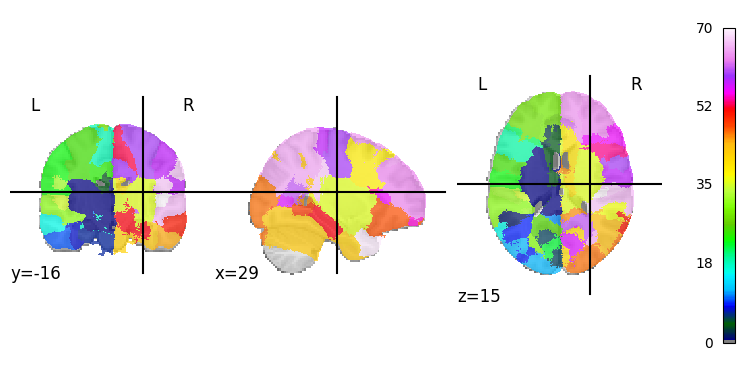

In [13]:
plotting.plot_roi(dk)

In [2]:
hcpmmp1_basic = nib.load('../../divfreqBERT/data/atlas/MMP_in_MNI_corr.nii.gz')
#hcpmmp1_half = nib.load('MMP_in_MNI_symmetrical_1.nii.gz')
#schaefer = nib.load('Schaefer2018_400Parcels_17Networks_order_FSLMNI152_2mm.nii.gz')

In [3]:
hcpmmp1_basic_array = hcpmmp1_basic.get_fdata()
# hcpmmp1_half_array = hcpmmp1_half.get_fdata()
# schaefer_array = schaefer.get_fdata()

In [4]:
print(hcpmmp1_basic_array.shape)
# print(hcpmmp1_half_array.shape)
# print(schaefer_array.shape)

(256, 256, 256)


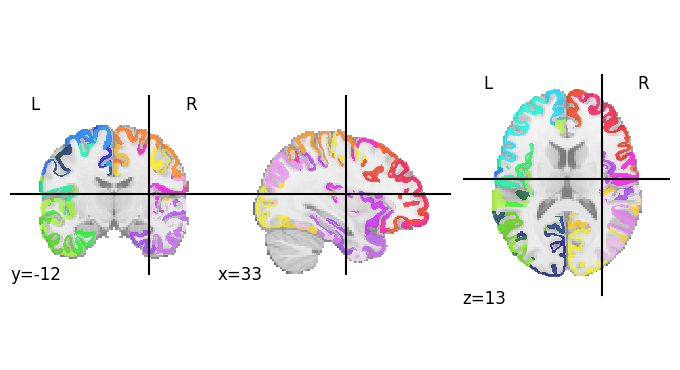

In [6]:
plotting.plot_roi(hcpmmp1_basic)

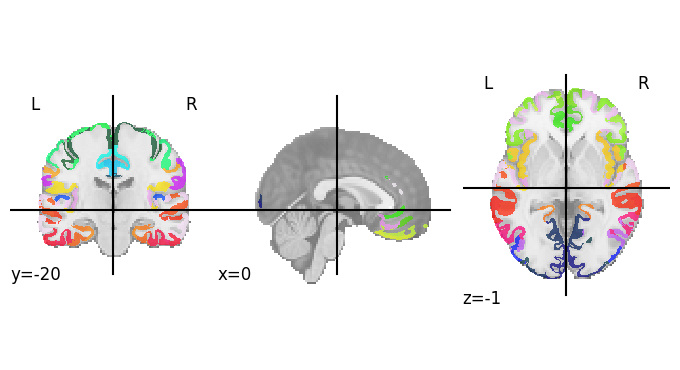

In [13]:
plotting.plot_roi(hcpmmp1_half)

In [5]:
hcp = nib.load('/storage/bigdata/S1200/HCP_S1200_task_fMRI/896879/MNINonLinear/Results/tfMRI_MOTOR_RL/tfMRI_MOTOR_RL.nii.gz')

In [6]:
hcp.get_fdata().shape

(91, 109, 91, 284)

In [14]:
resampled_atlas = resample_img(dk, target_affine=hcp.affine, target_shape=hcp.get_fdata().shape[:-1], interpolation='nearest', copy=True, order='F', clip=True, fill_value=0, force_resample=False)

/tmp/ipykernel_3849779/2004009806.py:1: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_atlas = resample_img(dk, target_affine=hcp.affine, target_shape=hcp.get_fdata().shape[:-1], interpolation='nearest', copy=True, order='F', clip=True, fill_value=0, force_resample=False)


In [15]:
resampled_atlas.get_fdata().shape

(91, 109, 91)

In [16]:
set(resampled_atlas.get_fdata().flatten())

{np.float64(0.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0),
 np.float64(11.0),
 np.float64(12.0),
 np.float64(13.0),
 np.float64(14.0),
 np.float64(15.0),
 np.float64(16.0),
 np.float64(17.0),
 np.float64(18.0),
 np.float64(19.0),
 np.float64(20.0),
 np.float64(21.0),
 np.float64(22.0),
 np.float64(23.0),
 np.float64(24.0),
 np.float64(25.0),
 np.float64(26.0),
 np.float64(27.0),
 np.float64(28.0),
 np.float64(29.0),
 np.float64(30.0),
 np.float64(31.0),
 np.float64(32.0),
 np.float64(33.0),
 np.float64(34.0),
 np.float64(35.0),
 np.float64(36.0),
 np.float64(37.0),
 np.float64(38.0),
 np.float64(39.0),
 np.float64(40.0),
 np.float64(41.0),
 np.float64(42.0),
 np.float64(43.0),
 np.float64(44.0),
 np.float64(45.0),
 np.float64(46.0),
 np.float64(47.0),
 np.float64(48.0),
 np.float64(49.0),
 np.float64(50.0),
 np.float64(51.0),
 np.float64(52.0),
 np

In [17]:
len(set(resampled_atlas.get_fdata().flatten()))

71

In [18]:
output_filename = "../data/atlas/DK_for_HCP.nii.gz"
nib.save(resampled_atlas, output_filename)